In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
distances = np.array([[0, 1, 0.9, 3],
                        [1, 0, 2, 0.8],
                        [0.9, 2, 0, 0.5],
                        [3, 0.8, 0.5, 0]])

In [4]:
def check_valid_solution(key_string):
    state = [int(key_string[k]) for k in range(len(key_string))]
    state = np.reshape(state, (4,4))
    timeConstraints = np.sum(state,axis=0)
    spaceConstraints = np.sum(state,axis=1)
    return np.array_equal(spaceConstraints,np.ones(4,dtype=int)) and np.array_equal(timeConstraints,np.ones(4,dtype=int))
def key_to_sol(key_string):
    state = [int(key_string[k]) for k in range(len(key_string))]
    state = np.reshape(list(reversed(state)), (4,4))
    if not check_valid_solution(key_string):
        return None
    sol = [np.where(state.T[i] == 1)[0].tolist()[0] for i in range(4)]
    return sol

def costFunction(key_string):
    sol = key_to_sol(key_string)
    if sol is None:
        return 1e6
    cost = 0
    for t in range(4):
        cost += distances[sol[t],sol[(t+1) % 4]]
    return cost

In [ ]:
def circuit(M,T):
    qc = QuantumCircuit(16)

    #Préparer l'état fondamental de H_i=-\sum_{i,j}^NX_{i,j} qui est l'état |+>^{N^2}
    qc.h([i for i in range(16)])

    return qc

In [182]:
qcSol = circuit(300,20)
state = Statevector.from_instruction(qcSol)
dictState = state.probabilities_dict()

In [ ]:
maxKey = max(dictState, key=dictState.get)
maxProb = dictState[maxKey]
print("État le plus probable:", maxKey, "avec une probabilité de", maxProb)


Most probable state: 0100100000100001 with probability 0.22561438013823668


Valid solution found: [0, 1, 3, 2]  with cost 3.1999999999999997 and frequency 0.22561438013823668
Valid solution found: [0, 2, 3, 1]  with cost 3.2 and frequency 0.22561438013822574
Valid solution found: [0, 3, 2, 1]  with cost 6.5 and frequency 0.01581983864256606
Valid solution found: [0, 1, 2, 3]  with cost 6.5 and frequency 0.01581983864256599
Valid solution found: [0, 2, 1, 3]  with cost 6.7 and frequency 0.007151437437039511
Valid solution found: [0, 3, 1, 2]  with cost 6.7 and frequency 0.007151437437039463


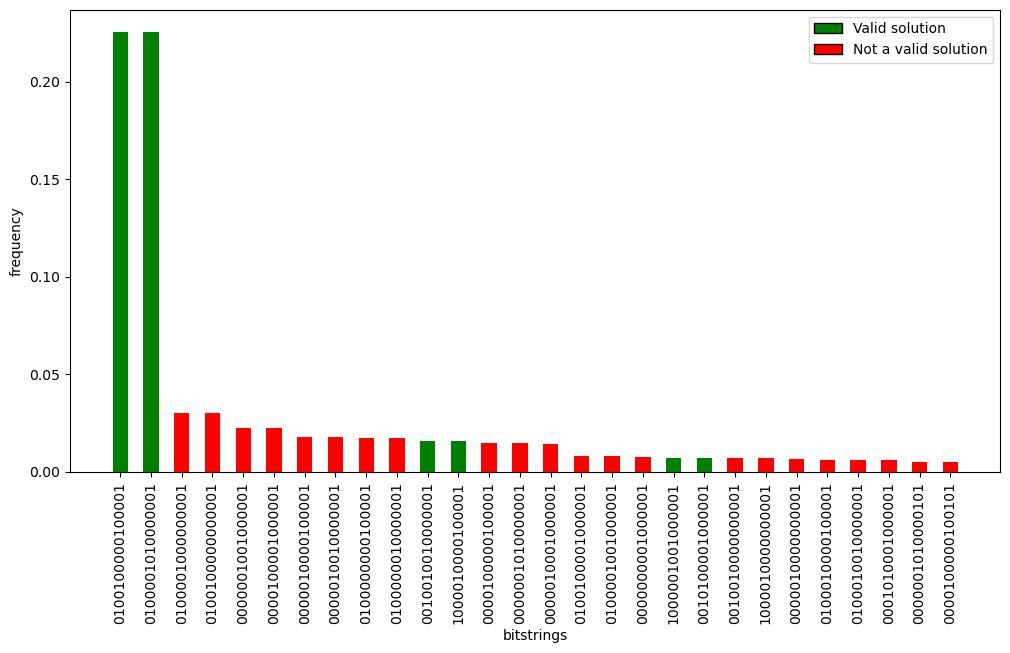

In [ ]:
most_freq = {k: v for k, v in dictState.items() if v > 0.005}
sorted_dict = dict(sorted(most_freq.items(), key=lambda item: item[1], reverse=True))
color_dict = {}
found_best_bitstrings = []
countsGoodSolution = 0 
for key in sorted_dict:
    if check_valid_solution(key):
        print("Solution valide trouvée:", key_to_sol(key)," avec coût", costFunction(key), "et fréquence", sorted_dict[key])
        color_dict.update({key : "g"})
        countsGoodSolution += sorted_dict[key]
    else:
        color_dict.update({key : "r"})
plt.figure(figsize=(12, 6))
plt.xlabel("bitstrings")
plt.ylabel("Probabilité")
plt.bar(sorted_dict.keys(), np.array(list(sorted_dict.values())), width=0.5, color=color_dict.values())
plt.xticks(rotation="vertical")
#create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in ['g','r']]
labels= ["Solution valide", "Pas une solution valide"]
plt.legend(handles, labels)
plt.show()